<a href="https://colab.research.google.com/github/stephenchen0814/04-LinearReg_Salary/blob/main/KNN%2C%20K-means%2C%20Spectral%20clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import pandas as pd
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,silhouette_samples
from sklearn.model_selection import GridSearchCV
from sklearn.datasets import make_blobs, make_moons, make_circles
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.inspection import DecisionBoundaryDisplay
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
dataset=datasets.load_iris()
X = dataset.data
y = dataset.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20)

In [3]:
param_dist  = {
              'n_neighbors': np.arange(1,20,1),
              'metric' :[ 'l1', 'l2', 'cosine']
             }

model = KNeighborsClassifier()
tree_cv = GridSearchCV(model, param_dist, cv=5)

tree_cv.fit(X_train, y_train)
print("Tuned KNN Parameters: {}".format(tree_cv.best_params_))
print("Best score is {}".format(tree_cv.best_score_))

Tuned KNN Parameters: {'metric': 'l1', 'n_neighbors': np.int64(3)}
Best score is 0.9916666666666668


In [4]:
knn=KNeighborsClassifier(n_neighbors=19, metric='cosine')
knn.fit (X_train, y_train)

KNeighborsClassifier(metric='cosine', n_neighbors=19)

In [5]:
predictions = knn.predict(X_test)
accuracy_score(y_test, predictions)

0.9333333333333333

In [7]:
def metricrbf(x,y):
    return 1-np.exp(-1*np.linalg.norm(x-y)**2/2)

knnrbf=KNeighborsClassifier(n_neighbors=6, metric=metricrbf)
knnrbf.fit(X_train, y_train)

KNeighborsClassifier(metric=<function metricrbf at 0x7a9018c74b80>,
                     n_neighbors=6)

In [8]:
predictions = knnrbf.predict(X_test)
accuracy_score(y_test, predictions)

0.9

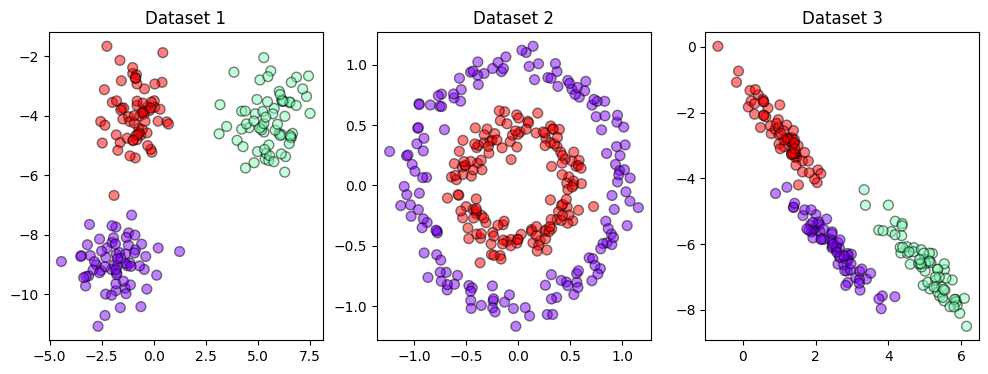

In [10]:
X1, y1 = make_blobs(n_samples=200, centers=3,random_state=40, cluster_std=0.9)
X2, y2  = make_circles(n_samples=300, factor=.5, noise=.08,)
T=np.array([[0.6, -0.6],[-0.4, 0.8]])
X3=np.dot(X1,T)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.scatter(X1[:, 0], X1[:, 1], c=y1, s=50, cmap='rainbow', edgecolor='black',alpha=.5)
ax1.set_title("Dataset 1")
ax2.scatter(X2[:, 0], X2[:, 1], c=y2, s=50, cmap='rainbow', edgecolor='black',alpha=.5)
ax2.set_title("Dataset 2")
ax3.scatter(X3[:, 0], X3[:, 1], c=y1, s=50, cmap='rainbow', edgecolor='black',alpha=.5)
ax3.set_title("Dataset 3")
plt.show()

In [11]:
classifiers_x1=[
    KMeans(n_clusters=2, random_state=0, n_init="auto"),
    KMeans(n_clusters=3, random_state=0, n_init="auto"),
    KMeans(n_clusters=4, random_state=0, n_init="auto")]

classifiers_x2=[
    KMeans(n_clusters=2, random_state=0, n_init="auto"),
    KMeans(n_clusters=3, random_state=0, n_init="auto"),
    KMeans(n_clusters=4, random_state=0, n_init="auto")]

classifiers_x3=[
    KMeans(n_clusters=2, random_state=0, n_init="auto"),
    KMeans(n_clusters=3, random_state=0, n_init="auto"),
    KMeans(n_clusters=4, random_state=0, n_init="auto")]

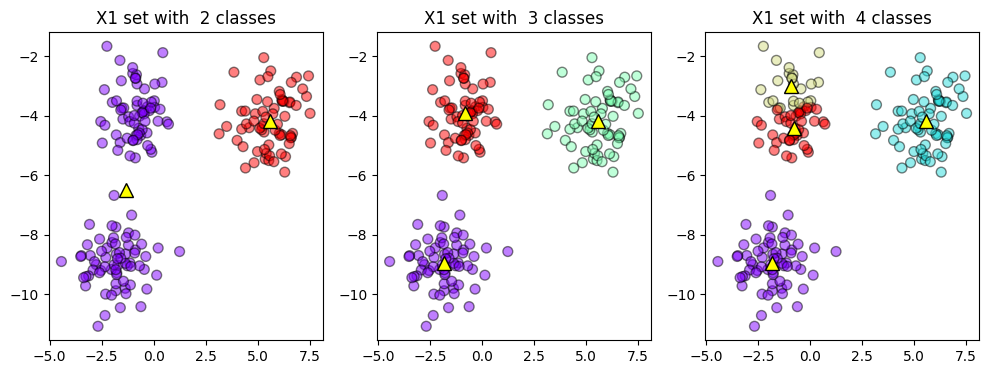

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
i=0
for classifier in classifiers_x1:
    y_pred=classifier.fit_predict(X1)
    k_means_cluster_centers = classifier.cluster_centers_

    ax[i].scatter(X1[:, 0], X1[:, 1],
                s=50, c=y_pred,cmap='rainbow',edgecolors="k",alpha=.5)
    ax[i].plot(
        k_means_cluster_centers[:,0],
        k_means_cluster_centers[:,1],
        "^",
        markerfacecolor="yellow",
        markeredgecolor="k",
        markersize=10,
    )
    ax[i].set_title(f'X1 set with  {i+2} classes')
    i+=1

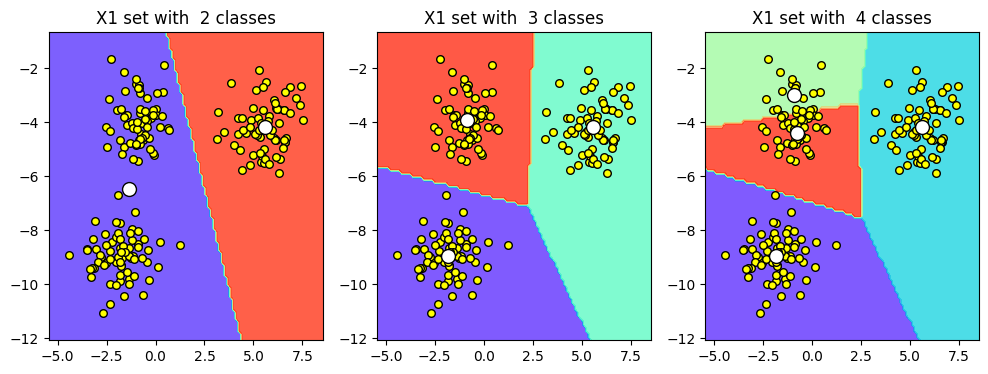

In [13]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
i=0
for classifier in classifiers_x1:
    classifier.fit(X1)
    k_means_cluster_centers = classifier.cluster_centers_
    disp=DecisionBoundaryDisplay.from_estimator(
            classifier,
            X1,
            response_method="predict",
            cmap=plt.cm.rainbow,
            alpha=0.8,
            ax=ax[i]
        )
    disp.ax_.plot(
        k_means_cluster_centers[:,0],
        k_means_cluster_centers[:,1],
        "o",
        markerfacecolor="w",
        markeredgecolor="k",
        markersize=10,
    )
    disp.ax_.scatter(X1[:, 0], X1[:, 1],
                s=30, c='yellow', cmap='rainbow',edgecolors="k")
    ax[i].set_title(f'X1 set with  {i+2} classes')
    i+=1

plt.show()

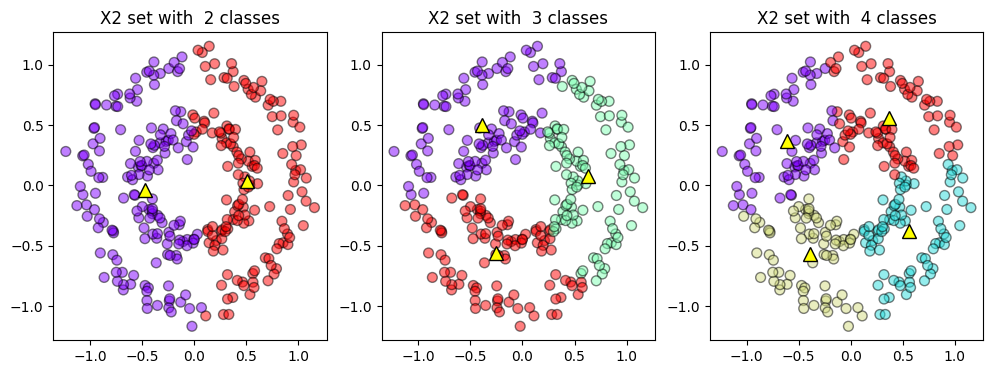

In [14]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
i=0
for classifier in classifiers_x2:
    y_pred=classifier.fit_predict(X2)
    k_means_cluster_centers = classifier.cluster_centers_

    ax[i].scatter(X2[:, 0], X2[:, 1],
                s=50, c=y_pred,cmap='rainbow',edgecolors="k",alpha=.5)
    ax[i].plot(
        k_means_cluster_centers[:,0],
        k_means_cluster_centers[:,1],
        "^",
        markerfacecolor="yellow",
        markeredgecolor="k",
        markersize=10,
    )
    ax[i].set_title(f'X2 set with  {i+2} classes')
    i+=1

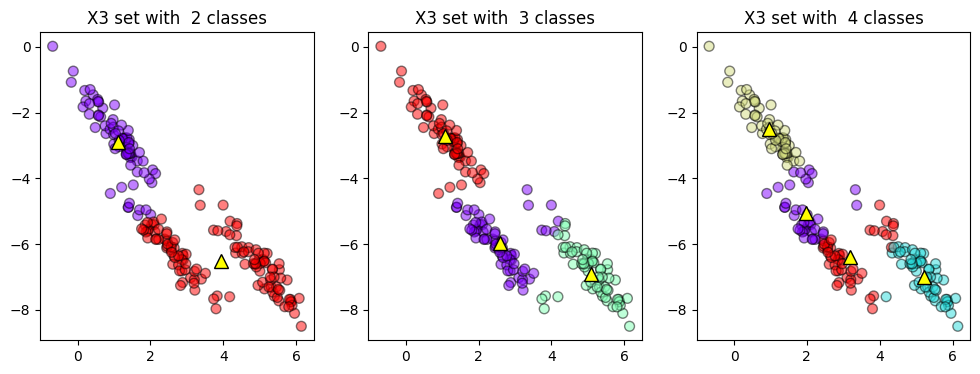

In [15]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
i=0
for classifier in classifiers_x3:
    y_pred=classifier.fit_predict(X3)
    k_means_cluster_centers = classifier.cluster_centers_

    ax[i].scatter(X3[:, 0], X3[:, 1],
                s=50, c=y_pred,cmap='rainbow',edgecolors="k",alpha=.5)
    ax[i].plot(
        k_means_cluster_centers[:,0],
        k_means_cluster_centers[:,1],
        "^",
        markerfacecolor="yellow",
        markeredgecolor="k",
        markersize=10,
    )
    ax[i].set_title(f'X3 set with  {i+2} classes')
    i+=1

In [16]:
def rbf_kernel(X, gamma=1.0):
    pairwise_sq_dists = np.sum((X[:, np.newaxis] - X[np.newaxis, :]) ** 2, axis=2)
    return np.exp(-gamma * pairwise_sq_dists)

W = rbf_kernel(X3, gamma=5)
D = np.diag(np.sum(W, axis=1))
L = D - W
D_inv_sqrt = np.diag(1/np.sqrt(np.diag(D)))
Lambdas, V = np.linalg.eig(np.matmul(np.matmul(D_inv_sqrt, W), D_inv_sqrt))

In [17]:
K=3
ind = np.argsort(np.linalg.norm(np.reshape(Lambdas, (1, len(Lambdas))), axis=0))
V_K = np.real(V[:, ind[-K:]])
V_K = V_K/np.reshape(np.linalg.norm(V_K, axis=1), (V_K.shape[0], 1))

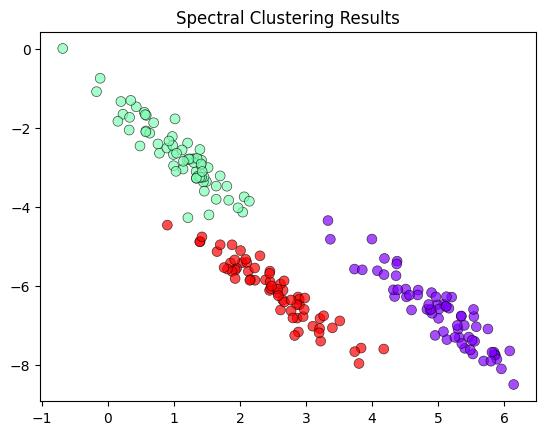

In [18]:
kmeans = KMeans(n_clusters=K)
kmeans.fit(V_K)
labels = kmeans.labels_

# Plot the results
plt.scatter(X3[:, 0], X3[:, 1], c=labels, s=50, cmap='rainbow', lw=0.5, edgecolor='k',alpha=.7)
plt.title("Spectral Clustering Results")
plt.show()

In [19]:
classifiers_x1_sc=[
    SpectralClustering(n_clusters=3, affinity='nearest_neighbors'),
    SpectralClustering(n_clusters=3, affinity='rbf', gamma=5),
    SpectralClustering(n_clusters=3, affinity='rbf', gamma=40)]

classifiers_x2_sc=[
    SpectralClustering(n_clusters=2, affinity='nearest_neighbors'),
    SpectralClustering(n_clusters=2, gamma=10),
    SpectralClustering(n_clusters=2, gamma=70)]

classifiers_x3_sc=[
    SpectralClustering(n_clusters=3, affinity='nearest_neighbors'),
    SpectralClustering(n_clusters=3, gamma=1),
    SpectralClustering(n_clusters=3, gamma=5)]

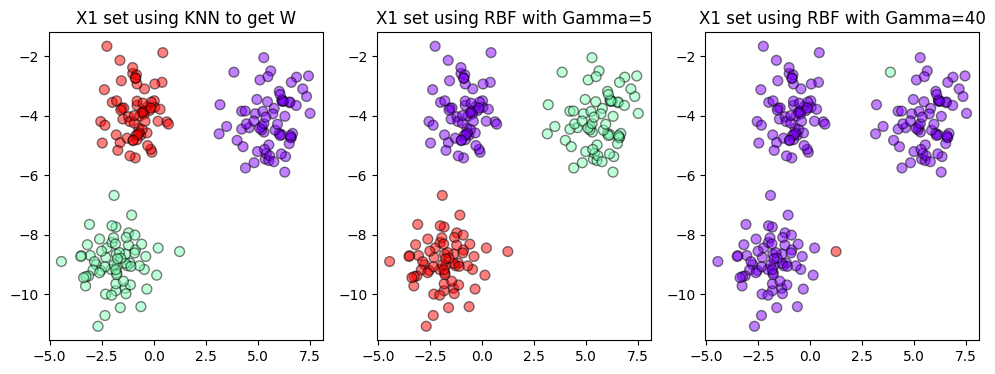

In [20]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
i=0
g=[5,40]
for classifier in classifiers_x1_sc:
    y_pred=classifier.fit_predict(X1)

    ax[i].scatter(X1[:, 0], X1[:, 1],
                s=50, c=y_pred,cmap='rainbow',edgecolors="k",alpha=.5)

    if i==0:
        ax[i].set_title(f'X1 set using KNN to get W')
    else:
        ax[i].set_title(f'X1 set using RBF with Gamma={g[i-1]}')
    i+=1

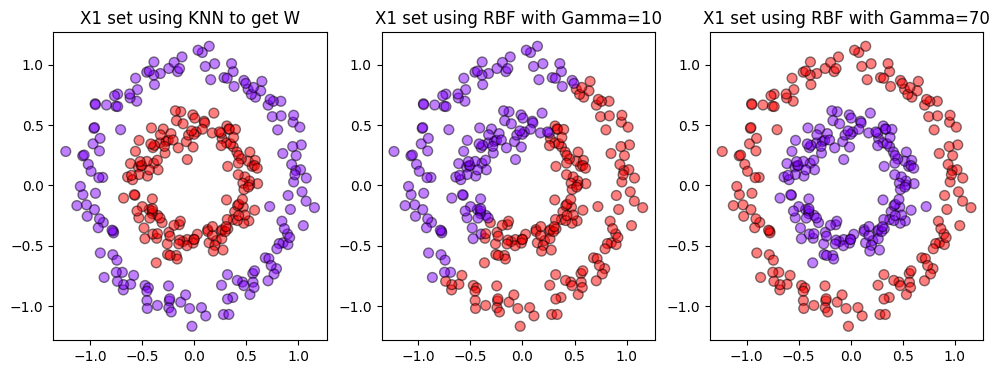

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
i=0
g=[10,70]
for classifier in classifiers_x2_sc:
    y_pred=classifier.fit_predict(X2)

    ax[i].scatter(X2[:, 0], X2[:, 1],
                s=50, c=y_pred,cmap='rainbow',edgecolors="k",alpha=.5)

    if i==0:
        ax[i].set_title(f'X1 set using KNN to get W')
    else:
        ax[i].set_title(f'X1 set using RBF with Gamma={g[i-1]}')
    i+=1

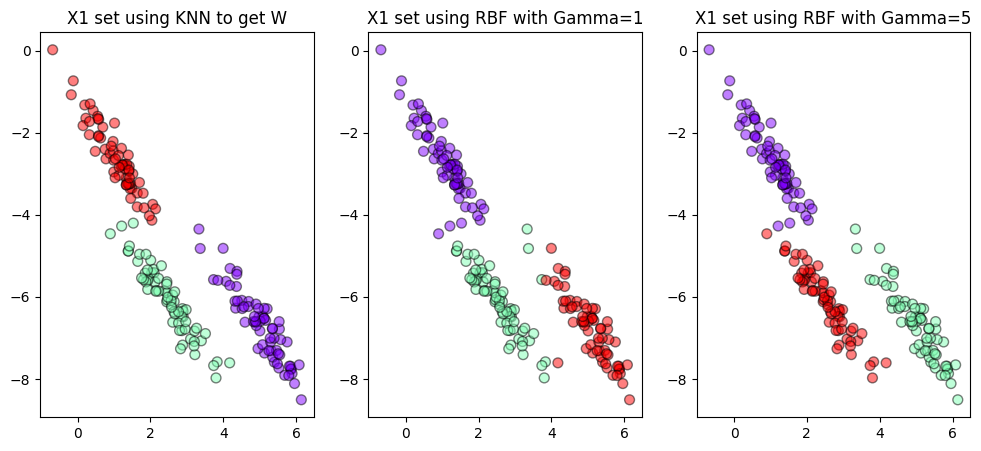

In [23]:
fig, ax = plt.subplots(1, 3, figsize=(12, 5))
i=0
g=[1,5]
for classifier in classifiers_x3_sc:
    y_pred=classifier.fit_predict(X3)

    ax[i].scatter(X3[:, 0], X3[:, 1],
                s=50, c=y_pred,cmap='rainbow',edgecolors="k",alpha=.5)

    if i==0:
        ax[i].set_title(f'X1 set using KNN to get W')
    else:
        ax[i].set_title(f'X1 set using RBF with Gamma={g[i-1]}')
    i+=1

In [24]:
distortions = []
for i in range(1, 11):
    km = KMeans(n_clusters=i,
    n_init='auto',
    random_state=0)
    km.fit(X3)
    distortions.append(km.inertia_)

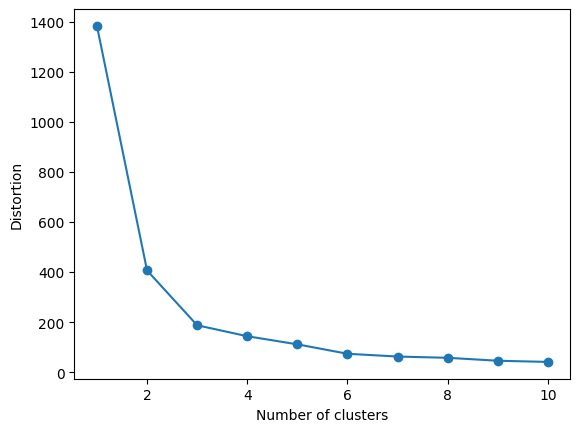

In [27]:
plt.plot(range(1,11), distortions, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Distortion')
plt.show()

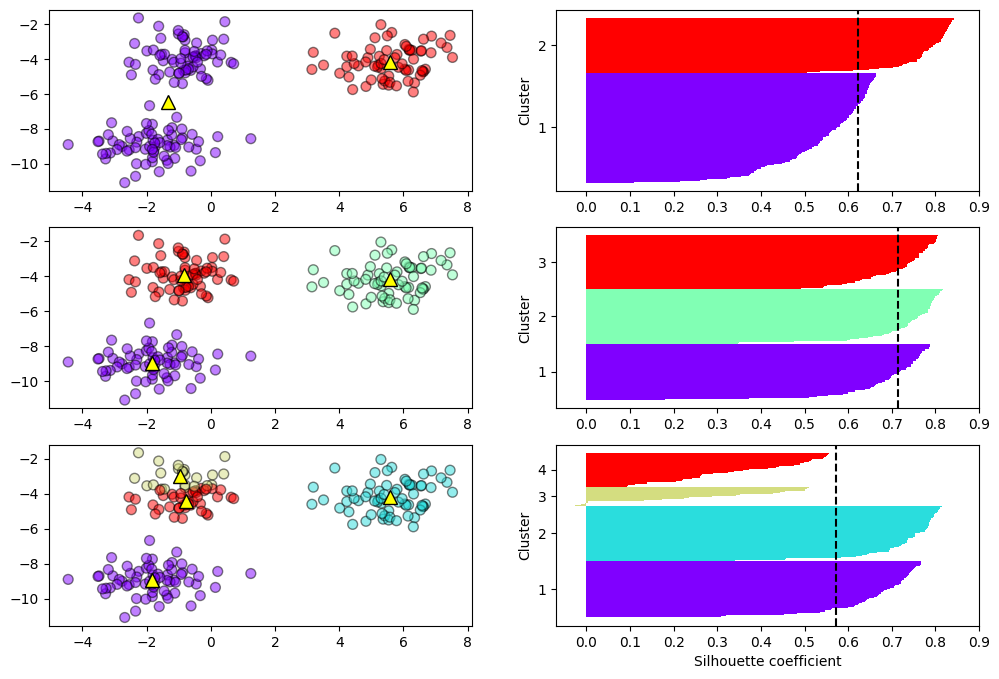

In [29]:
fig, ax = plt.subplots(3, 2, figsize=(12, 8), sharex='col')
i=0
for classifier in classifiers_x1:
    y_pred=classifier.fit_predict(X1)
    k_means_cluster_centers = classifier.cluster_centers_
    cluster_labels = np.unique(y_pred)
    n_clusters = cluster_labels.shape[0]
    silhouette_vals = silhouette_samples(X1, y_pred, metric='euclidean')
    y_ax_lower, y_ax_upper = 0, 0
    yticks = []

    ax[i,0].scatter(X1[:, 0], X1[:, 1],
                s=50, c=y_pred,cmap='rainbow',edgecolors="k",alpha=.5)
    ax[i,0].plot(
        k_means_cluster_centers[:,0],
        k_means_cluster_centers[:,1],
        "^",
        markerfacecolor="yellow",
        markeredgecolor="k",
        markersize=10,
    )

    for n, c in enumerate(cluster_labels):
        c_silhouette_vals = silhouette_vals[y_pred == c]
        c_silhouette_vals.sort()
        y_ax_upper += len(c_silhouette_vals)
        color = plt.cm.rainbow(float(n) / (n_clusters-1))
        ax[i,1].barh(range(y_ax_lower, y_ax_upper),
            c_silhouette_vals,
            height=1.0,
            color=color)
        yticks.append((y_ax_lower + y_ax_upper) / 2.)
        y_ax_lower += len(c_silhouette_vals)
    silhouette_avg = np.mean(silhouette_vals)
    ax[i,1].axvline(silhouette_avg,
        color="k",
        linestyle="--")
    ax[i,1].set_yticks(yticks, cluster_labels + 1)
    ax[i,1].set_ylabel('Cluster')
    i+=1

ax[2,1].set_xlabel('Silhouette coefficient')
ax[2,1].set_xticks(np.arange(0,1,0.1))
for ax in ax.flatten():
    ax.xaxis.set_tick_params(labelbottom=True)
plt.show()

In [30]:
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

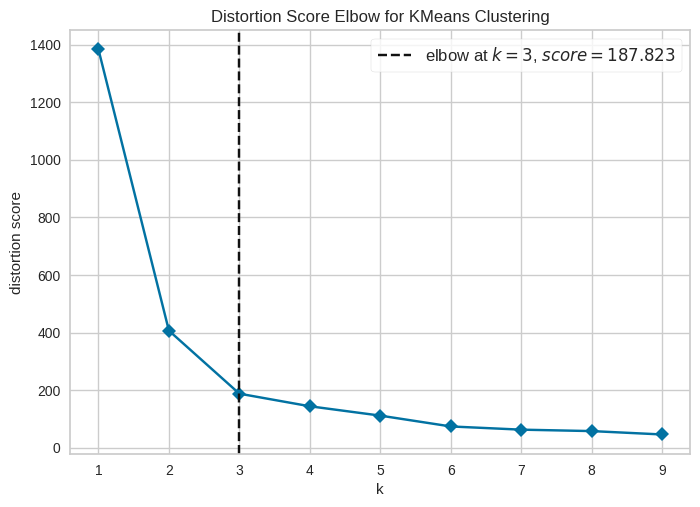

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [31]:
model=KMeans(n_init='auto',random_state=0)
elbow=KElbowVisualizer(model, k=(1,10), timings=False)
elbow.fit(X3)
elbow.show()

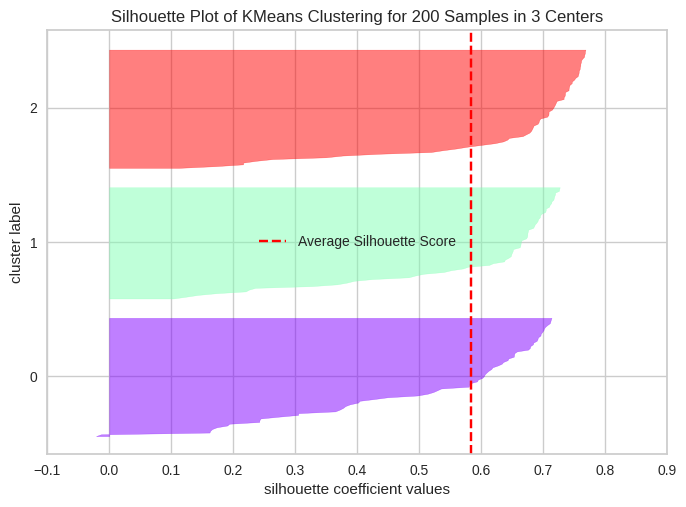

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 200 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [32]:
model=KMeans(n_clusters=3,n_init='auto',random_state=0)
sil=SilhouetteVisualizer(model, colors='rainbow')
sil.fit(X3)
sil.show()